<a href="https://colab.research.google.com/github/sunilchhajwani/ChatGPT/blob/v2-dev/Copy_of_chest_x_ray_tb_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# 🧠 TB CHEST X-RAY CLASSIFICATION (VGG16) — ONE-CELL VERSION
# (Fully updated for TensorFlow 2.15+ / Keras 3)
# ==========================================================

# 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2️⃣ Libraries
# Install required libraries explicitly
!pip install -q tensorflow keras scikit-learn matplotlib kaggle
import os, pickle, numpy as np
import matplotlib.pyplot as plt

# Corrected imports for Keras/TensorFlow 2.x/3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model

# 3️⃣ AUTO-DETECT DATASET
def find_tb_folder(search_roots=['/content', '/content/drive/MyDrive']):
    for root in search_roots:
        for r, dirs, files in os.walk(root):
            if 'Normal' in dirs and 'Tuberculosis' in dirs:
                return r
    return None

data_dir = find_tb_folder()

# 4️⃣ DOWNLOAD FROM KAGGLE IF NOT FOUND
if not data_dir:
    print("🔍 Dataset not found. Downloading from Kaggle…")
    from google.colab import files
    uploaded = files.upload()  # upload kaggle.json

    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    !kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset -p /content --force
    !unzip -qo /content/tuberculosis-tb-chest-xray-dataset.zip -d /content

    data_dir = find_tb_folder(['/content'])

print(f"✅ Dataset directory found: {data_dir}")

# 5️⃣ DATA GENERATORS (80/20 split)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

print("Classes:", train_data.class_indices)
print("Train samples:", train_data.samples)
print("Validation samples:", val_data.samples)

# 6️⃣ BUILD VGG16 TRANSFER LEARNING MODEL
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers:
    layer.trainable = False  # freeze base model

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# 7️⃣ CALLBACKS — AUTO SAVE BEST MODEL
checkpoint_path = "/content/drive/MyDrive/TB_VGG16_BestModel.h5"

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# 8️⃣ TRAIN MODEL
history = model.fit(
    train_data,
    epochs=15,
    validation_data=val_data,
    callbacks=[checkpoint, early_stop]
)

# 9️⃣ SAVE FINAL MODEL + HISTORY
model.save("/content/drive/MyDrive/TB_VGG16_FinalModel.h5")

with open("/content/drive/MyDrive/TB_VGG16_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("🎉 Training complete. Best model saved to Google Drive!")

# 🔟 TESTING FUNCTION
def test_xray(img_path):
    print("\n🩻 Testing:", img_path)
    # Corrected usage of load_img and img_to_array
    img = image.load_img(img_path, target_size=(224,224))
    img_arr = image.img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    pred = model.predict(img_arr)[0][0]

    plt.imshow(image.load_img(img_path))
    plt.axis('off')

    if pred > 0.5:
        plt.title(f"🧫 TB POSITIVE\nScore = {pred:.4f}")
    else:
        plt.title(f"✅ NORMAL\nScore = {pred:.4f}")
    plt.show()

print("\n📌 To test: test_xray('/path/to/image.jpg')")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Dataset not found. Downloading from Kaggle…


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
 96% 638M/663M [00:03<00:00, 198MB/s]
100% 663M/663M [00:06<00:00, 101MB/s]
✅ Dataset directory found: /content/TB_Chest_Radiography_Database
Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Classes: {'Normal': 0, 'Tuberculosis': 1}
Train samples: 3360
Validation samples: 840
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

...

105/105 ━━━━━━━━━━━━━━━━━━━━ 90s 857ms/step - accuracy: 0.9619 - loss: 0.1115 - val_accuracy: 0.9631 - val_loss: 0.1077
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.9742 - loss: 0.0845
Epoch 7: val_accuracy did not improve from 0.96310
105/105 ━━━━━━━━━━━━━━━━━━━━ 92s 876ms/step - accuracy: 0.9742 - loss: 0.0846 - val_accuracy: 0.9548 - val_loss: 0.1068
Epoch 8/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.9696 - loss: 0.0781
Epoch 8: val_accuracy did not improve from 0.96310
105/105 ━━━━━━━━━━━━━━━━━━━━ 88s 836ms/step - accuracy: 0.9696 - loss: 0.0781 - val_accuracy: 0.9583 - val_loss: 0.1032
Epoch 9/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.9682 - loss: 0.0930
Epoch 9: val_accuracy did not improve from 0.96310
105/105 ━━━━━━━━━━━━━━━━━━━━ 88s 838ms/step - accuracy: 0.9681 - loss: 0.0931 - val_accuracy: 0.9536 - val_loss: 0.1116
Epoch 10/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.9719 - loss: 0.0829
Epoch 10: val_

105/105 ━━━━━━━━━━━━━━━━━━━━ 91s 866ms/step - accuracy: 0.9705 - loss: 0.0814 - val_accuracy: 0.9702 - val_loss: 0.0891
Epoch 12/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.9763 - loss: 0.0795
Epoch 12: val_accuracy improved from 0.97024 to 0.97500, saving model to /content/drive/MyDrive/TB_VGG16_BestModel.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 89s 853ms/step - accuracy: 0.9763 - loss: 0.0795 - val_accuracy: 0.9750 - val_loss: 0.0736
Epoch 13/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.9791 - loss: 0.0603
Epoch 13: val_accuracy did not improve from 0.97500
105/105 ━━━━━━━━━━━━━━━━━━━━ 89s 847ms/step - accuracy: 0.9791 - loss: 0.0604 - val_accuracy: 0.9643 - val_loss: 0.0970
Epoch 14/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.9711 - loss: 0.0804
Epoch 14: val_accuracy did not improve from 0.97500
105/105 ━━━━━━━━━━━━━━━━━━━━ 89s 850ms/step - accuracy: 0.9712 - loss: 0.0804 - val_accuracy: 0.9321 - val_loss: 0.1781
Epoch 15/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.9785 - loss: 0.0672
Epoch 15: val_accuracy improved from 0.97500 to 0.97976, saving model to /content/drive/MyDrive/TB_VGG16_BestModel.h5


105/105 ━━━━━━━━━━━━━━━━━━━━ 93s 887ms/step - accuracy: 0.9785 - loss: 0.0672 - val_accuracy: 0.9798 - val_loss: 0.0579
Restoring model weights from the end of the best epoch: 15.


🎉 Training complete. Best model saved to Google Drive!

📌 To test: test_xray('/path/to/image.jpg')


Saving 1.jpg to 1.jpg

🩻 Testing: 1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129515 (\N{PETRI DISH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


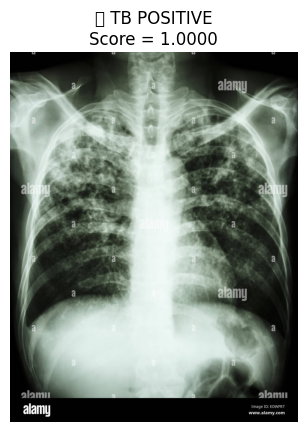

In [ ]:
from google.colab import files
uploaded = files.upload()    # Upload any chest X-ray image (jpg/png)

for fn in uploaded.keys():
    test_xray(fn)
